In [1]:
# CELL 1 — Environment setup: upload & unzip DriftSense_Prepared
# ---------------------------------------------------------------------------
from google.colab import files
import os, zipfile
from google.colab import drive
drive.mount('/content/drive')
ZIP_PATH = '/content/drive/MyDrive/DriftSense_Prepared.zip'
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
  z.extractall('/content')

print(os.listdir('/content'))


Mounted at /content/drive
['.config', 'drive', 'DriftSense_Prepared', 'sample_data']


In [2]:
# CELL 2 — Imports
# ---------------------------------------------------------------------------
import os, glob, random, math, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)


Using device: cuda


In [3]:
# CELL 3 — Locate dataset root, build a robust path resolver, config
# ---------------------------------------------------------------------------
def find_dataset_root(start='/content'):
    for dirpath, dirnames, filenames in os.walk(start):
        if 'train.csv' in filenames and 'test.csv' in filenames and 'valid.csv' in filenames:
            return dirpath
    raise FileNotFoundError("Could not find train.csv/test.csv/valid.csv anywhere under /content. "
                             "Check the zip extracted correctly (see CELL 1 output).")

DATASET_ROOT = find_dataset_root()
print("Dataset root:", DATASET_ROOT)
print(os.listdir(DATASET_ROOT))

# Each split folder (train/test/valid) holds reference/ and search/ subfolders on disk.
SPLIT_DIR_ALIASES = {'train': ['train'], 'valid': ['valid', 'val'], 'test': ['test']}
SUBDIR_ALIASES    = {'reference': ['reference', 'references'],
                      'search':    ['search', 'searches']}

def resolve_path(split, subdir_key, filename):
    for split_alias in SPLIT_DIR_ALIASES.get(split, [split]):
        for sub_alias in SUBDIR_ALIASES.get(subdir_key, [subdir_key]):
            candidate = os.path.join(DATASET_ROOT, split_alias, sub_alias, filename)
            if os.path.exists(candidate):
                return candidate
    return None

CONFIG = dict(
    SEARCH_SIZE   = 512,   # resize search image (1000x1000) to this for train/inference
    TEMPLATE_SIZE = None,  # computed below to keep physical scale consistent
    SCALE_RATIO   = 10.0,  # search_nm_per_pixel / reference_nm_per_pixel from the CSVs
    BATCH_SIZE    = 8,
    EPOCHS        = 15,
    LR            = 1e-3,
    ORIG_SIZE     = 1000.0,  # original search image is 1000x1000 px
)
footprint_px = CONFIG['ORIG_SIZE'] / CONFIG['SCALE_RATIO']   # ~100 px, matches x2-x1 in the CSVs
CONFIG['TEMPLATE_SIZE'] = int(round(footprint_px * CONFIG['SEARCH_SIZE'] / CONFIG['ORIG_SIZE']))
print(CONFIG)


Dataset root: /content/DriftSense_Prepared
['train', 'valid.csv', 'valid', 'test.csv', 'split_info.json', 'train.csv', 'test']
{'SEARCH_SIZE': 512, 'TEMPLATE_SIZE': 51, 'SCALE_RATIO': 10.0, 'BATCH_SIZE': 8, 'EPOCHS': 15, 'LR': 0.001, 'ORIG_SIZE': 1000.0}


In [4]:
# CELL 4 — Load train.csv / valid.csv / test.csv and resolve image paths
# ---------------------------------------------------------------------------
train_df = pd.read_csv(os.path.join(DATASET_ROOT, 'train.csv'))
valid_df = pd.read_csv(os.path.join(DATASET_ROOT, 'valid.csv'))
test_df  = pd.read_csv(os.path.join(DATASET_ROOT, 'test.csv'))

for name, df in [('train', train_df), ('valid', valid_df), ('test', test_df)]:
    if 'split' not in df.columns:
        df['split'] = name

meta = pd.concat([train_df, valid_df, test_df], ignore_index=True)
print(meta.shape)
print(meta['split'].value_counts())

def add_resolved_paths(df):
    ref_full, search_full, ok = [], [], []
    for _, row in df.iterrows():
        rp = resolve_path(row['split'], 'reference', row['reference_filename'])
        sp = resolve_path(row['split'], 'search',    row['search_image'])
        ref_full.append(rp); search_full.append(sp)
        ok.append(rp is not None and sp is not None)
    df = df.copy()
    df['ref_full_path'] = ref_full
    df['search_full_path'] = search_full
    df['paths_ok'] = ok
    return df

meta = add_resolved_paths(meta)
print("Rows with resolvable image paths:", meta['paths_ok'].sum(), "/", len(meta))
missing = meta[~meta['paths_ok']]
if len(missing):
    print("WARNING — sample of unresolved rows (fix folder names in CELL 3 aliases if this is nonzero):")
    print(missing[['split', 'reference_filename', 'search_image']].head())

meta = meta[meta['paths_ok']].reset_index(drop=True)
train_df = meta[meta['split'] == 'train'].reset_index(drop=True)
val_df   = meta[meta['split'] == 'valid'].reset_index(drop=True)
test_df  = meta[meta['split'] == 'test'].reset_index(drop=True)
print(len(train_df), len(val_df), len(test_df))


(750, 17)
split
train    525
test     120
valid    105
Name: count, dtype: int64
Rows with resolvable image paths: 750 / 750
525 105 120


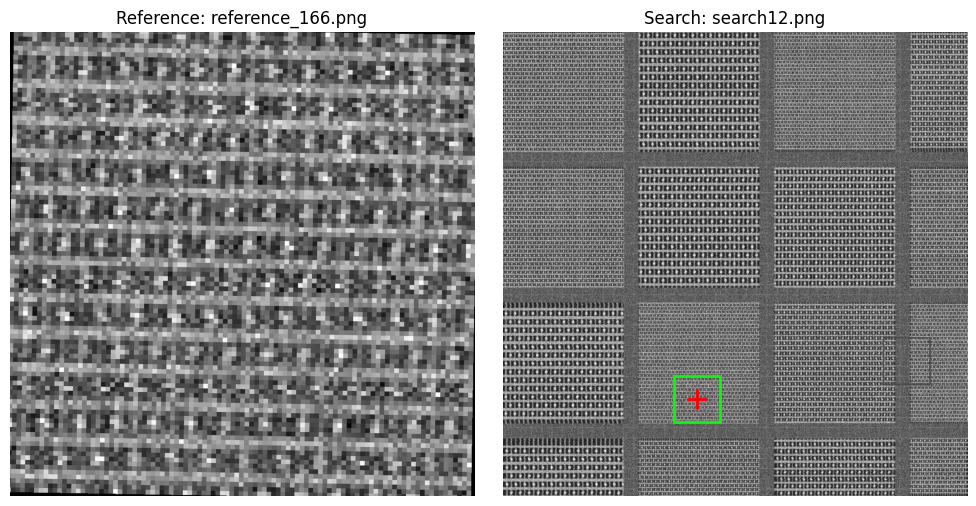

Ground truth center (x, y): 419.5 789.5


In [5]:
# CELL 5 — Visualize one sample pair to confirm ground truth aligns visually
# ---------------------------------------------------------------------------
sample = train_df.iloc[0]
ref_img = Image.open(sample['ref_full_path']).convert('L')
search_img = Image.open(sample['search_full_path']).convert('L')

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(ref_img, cmap='gray')
axes[0].set_title(f"Reference: {sample['reference_filename']}"); axes[0].axis('off')

axes[1].imshow(search_img, cmap='gray')
axes[1].set_title(f"Search: {sample['search_image']}")
w = sample['x2'] - sample['x1']
h = sample['y2'] - sample['y1']
rect = plt.Rectangle((sample['x1'], sample['y1']), w, h, edgecolor='lime', facecolor='none', linewidth=2)
axes[1].add_patch(rect)
axes[1].plot(sample['center_x'], sample['center_y'], 'r+', markersize=15, markeredgewidth=2)
axes[1].axis('off')
plt.tight_layout(); plt.show()
print("Ground truth center (x, y):", sample['center_x'], sample['center_y'])


In [6]:
# CELL 6 — PyTorch Dataset
# ---------------------------------------------------------------------------
class LocalizationDataset(Dataset):
    """
    Returns:
      template: [1, T, T]  - resized reference patch, at the same physical scale as the search image
      search:   [1, S, S]  - resized search image
      target_xy: [2]       - ground-truth (x, y) in NORMALIZED [0,1] coords w.r.t. the resized search image
    """
    def __init__(self, df, search_size, template_size, orig_size=1000.0, augment=False):
        self.df = df.reset_index(drop=True)
        self.S = search_size
        self.T = template_size
        self.orig_size = orig_size
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        ref = Image.open(row['ref_full_path']).convert('L')
        search = Image.open(row['search_full_path']).convert('L')

        # reference -> template: resize the FULL reference down to its footprint size
        # (mimics the 10x optical de-magnification, matching search-image pixel scale)
        template = ref.resize((self.T, self.T), Image.BILINEAR)
        search_r = search.resize((self.S, self.S), Image.BILINEAR)

        template = np.asarray(template, dtype=np.float32) / 255.0
        search_r = np.asarray(search_r, dtype=np.float32) / 255.0

        if self.augment:
            # light train-time augmentation: independent gaussian noise + brightness jitter
            template = np.clip(template + np.random.normal(0, 0.01, template.shape), 0, 1)
            search_r = np.clip(search_r + np.random.normal(0, 0.02, search_r.shape), 0, 1)
            if random.random() < 0.5:
                b = random.uniform(0.9, 1.1)
                search_r = np.clip(search_r * b, 0, 1)

        template_t = torch.from_numpy(template).unsqueeze(0).float()
        search_t = torch.from_numpy(search_r).unsqueeze(0).float()

        gt_x = row['center_x'] / self.orig_size
        gt_y = row['center_y'] / self.orig_size
        target = torch.tensor([gt_x, gt_y], dtype=torch.float32)

        return template_t, search_t, target

print("Dataset class ready.")


Dataset class ready.


In [7]:
# CELL 7 — Build DataLoaders
# ---------------------------------------------------------------------------
train_ds = LocalizationDataset(train_df, CONFIG['SEARCH_SIZE'], CONFIG['TEMPLATE_SIZE'], augment=True)
val_ds   = LocalizationDataset(val_df,   CONFIG['SEARCH_SIZE'], CONFIG['TEMPLATE_SIZE'], augment=False)
test_ds  = LocalizationDataset(test_df,  CONFIG['SEARCH_SIZE'], CONFIG['TEMPLATE_SIZE'], augment=False)

train_loader = DataLoader(train_ds, batch_size=CONFIG['BATCH_SIZE'], shuffle=True,  num_workers=2, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=CONFIG['BATCH_SIZE'], shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG['BATCH_SIZE'], shuffle=False, num_workers=2)

print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")
tb, sb, yb = next(iter(train_loader))
print("template batch:", tb.shape, "search batch:", sb.shape, "target batch:", yb.shape)


train=525  val=105  test=120
template batch: torch.Size([8, 1, 51, 51]) search batch: torch.Size([8, 1, 512, 512]) target batch: torch.Size([8, 2])


In [8]:
# CELL 8 — Model: Siamese cross-correlation localizer (SiamFC-style)
# ---------------------------------------------------------------------------
class ConvBlock(nn.Module):
    def __init__(self, c_in, c_out, k=3, stride=1, pool=False):
        super().__init__()
        layers = [nn.Conv2d(c_in, c_out, k, stride=stride, padding=k // 2, bias=False),
                  nn.BatchNorm2d(c_out), nn.ReLU(inplace=True)]
        if pool:
            layers.append(nn.MaxPool2d(2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class SharedBackbone(nn.Module):
    """Shared feature extractor applied to BOTH template and search image."""
    def __init__(self, c_out=64):
        super().__init__()
        self.net = nn.Sequential(
            ConvBlock(1, 16, k=5, stride=2),              # /2
            ConvBlock(16, 32, k=3, stride=1, pool=True),  # /4
            ConvBlock(32, 64, k=3, stride=1, pool=True),  # /8
            ConvBlock(64, c_out, k=3, stride=1),
        )

    def forward(self, x):
        return self.net(x)


class SiameseLocalizer(nn.Module):
    def __init__(self, feat_dim=64):
        super().__init__()
        self.backbone = SharedBackbone(feat_dim)

    def forward(self, template, search):
        f_t = self.backbone(template)   # [B, C, t, t]  (template feature map -> acts as a kernel)
        f_s = self.backbone(search)     # [B, C, h, w]  (search feature map)

        B, C, t, t2 = f_t.shape
        _, _, H, W = f_s.shape

        # depth-wise cross-correlation, per-sample (grouped conv trick)
        f_s_grouped = f_s.reshape(1, B * C, H, W)
        kernel = f_t.reshape(B * C, 1, t, t2)
        response = F.conv2d(f_s_grouped, kernel, groups=B * C)  # [1, B*C, h', w']
        response = response.reshape(B, C, response.shape[-2], response.shape[-1]).mean(dim=1, keepdim=True)

        heatmap = F.interpolate(response, size=(search.shape[-2], search.shape[-1]),
                                 mode='bilinear', align_corners=False)
        return heatmap


def soft_argmax_2d(heatmap):

    B, _, H, W = heatmap.shape
    flat = heatmap.view(B, -1)
    probs = F.softmax(flat, dim=1).view(B, 1, H, W)

    xs = torch.linspace(0, 1, W, device=heatmap.device).view(1, 1, 1, W)
    ys = torch.linspace(0, 1, H, device=heatmap.device).view(1, 1, H, 1)

    x = (probs * xs).sum(dim=[1, 2, 3])
    y = (probs * ys).sum(dim=[1, 2, 3])
    return torch.stack([x, y], dim=1), probs


model = SiameseLocalizer().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model built. Trainable params: {n_params:,}")


Model built. Trainable params: 60,656


In [9]:
# CELL 9 — Loss function
# ---------------------------------------------------------------------------
# Combines: (a) direct L2 regression on the soft-argmax coordinate and
#           (b) a heatmap loss pulling probability mass toward a small gaussian centered at
#               the ground truth - keeps training well-posed even with many look-alike peaks
#               in highly periodic (DRAM/FinFET-style) layouts.

def gaussian_target(H, W, cx, cy, sigma_px, device):
    ys = torch.arange(H, device=device).float().view(H, 1)
    xs = torch.arange(W, device=device).float().view(1, W)
    g = torch.exp(-(((xs - cx) ** 2 + (ys - cy) ** 2) / (2 * sigma_px ** 2)))
    return g / g.sum()

def loc_loss(heatmap, target_xy, coord_weight=1.0, heatmap_weight=1.0, sigma_px=8.0):
    B, _, H, W = heatmap.shape
    pred_xy, probs = soft_argmax_2d(heatmap)

    coord_l = F.mse_loss(pred_xy, target_xy)

    flat_log_probs = F.log_softmax(heatmap.view(B, -1), dim=1).view(B, 1, H, W)
    heat_l = 0.0
    for b in range(B):
        cx = target_xy[b, 0].item() * (W - 1)
        cy = target_xy[b, 1].item() * (H - 1)
        g = gaussian_target(H, W, cx, cy, sigma_px, heatmap.device)
        heat_l = heat_l - (g * flat_log_probs[b, 0]).sum()
    heat_l = heat_l / B

    total = coord_weight * coord_l + heatmap_weight * heat_l
    return total, coord_l.item(), heat_l.item(), pred_xy

print("Loss function ready.")


Loss function ready.


In [10]:
# CELL 10 — Training & evaluation loop
# ---------------------------------------------------------------------------
optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['LR'])
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CONFIG['EPOCHS'])

def pixel_error(pred_xy_norm, target_xy_norm, orig_size=1000.0):
    diff = (pred_xy_norm - target_xy_norm) * orig_size
    return torch.sqrt((diff ** 2).sum(dim=1))

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, total_err, n = 0.0, 0.0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for template, search, target in loader:
            template, search, target = template.to(device), search.to(device), target.to(device)
            heatmap = model(template, search)
            loss, coord_l, heat_l, pred_xy = loc_loss(heatmap, target)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            err = pixel_error(pred_xy.detach(), target).sum().item()
            total_loss += loss.item() * template.size(0)
            total_err += err
            n += template.size(0)
    return total_loss / n, total_err / n

print("Train/eval functions ready.")


Train/eval functions ready.


In [11]:
# CELL 11 — Run training
# ---------------------------------------------------------------------------
history = {'train_loss': [], 'val_loss': [], 'train_err': [], 'val_err': []}
best_val_err = float('inf')
os.makedirs('/content/outputs', exist_ok=True)
BEST_WEIGHTS_PATH = '/content/outputs/model_weights.pt'

for epoch in range(1, CONFIG['EPOCHS'] + 1):
    t0 = time.time()
    tr_loss, tr_err = run_epoch(train_loader, train=True)
    va_loss, va_err = run_epoch(val_loader, train=False)
    scheduler.step()

    history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
    history['train_err'].append(tr_err);   history['val_err'].append(va_err)

    if va_err < best_val_err:
        best_val_err = va_err
        torch.save({'model_state_dict': model.state_dict(), 'config': CONFIG}, BEST_WEIGHTS_PATH)
        tag = "  <- saved best"
    else:
        tag = ""

    print(f"Epoch {epoch:02d}/{CONFIG['EPOCHS']} | "
          f"train_loss={tr_loss:.4f} val_loss={va_loss:.4f} | "
          f"train_err={tr_err:.1f}px val_err={va_err:.1f}px | "
          f"{time.time()-t0:.1f}s{tag}")

print(f"\nBest validation pixel error: {best_val_err:.2f} px  (weights saved to {BEST_WEIGHTS_PATH})")


Epoch 01/15 | train_loss=12.3659 val_loss=11.0784 | train_err=381.1px val_err=306.1px | 26.3s  <- saved best
Epoch 02/15 | train_loss=11.8299 val_loss=11.1379 | train_err=364.3px val_err=337.9px | 25.9s
Epoch 03/15 | train_loss=11.5543 val_loss=11.0750 | train_err=363.9px val_err=324.2px | 23.2s
Epoch 04/15 | train_loss=11.4276 val_loss=11.4398 | train_err=366.4px val_err=351.3px | 25.1s
Epoch 05/15 | train_loss=11.2832 val_loss=11.1659 | train_err=361.9px val_err=324.1px | 25.2s
Epoch 06/15 | train_loss=11.0660 val_loss=11.2189 | train_err=349.4px val_err=326.7px | 23.6s
Epoch 07/15 | train_loss=10.9218 val_loss=10.8086 | train_err=349.8px val_err=293.8px | 25.5s  <- saved best
Epoch 08/15 | train_loss=10.7434 val_loss=10.9094 | train_err=345.2px val_err=288.6px | 24.9s  <- saved best
Epoch 09/15 | train_loss=10.5800 val_loss=11.2862 | train_err=333.3px val_err=321.9px | 23.6s
Epoch 10/15 | train_loss=10.4248 val_loss=10.8797 | train_err=330.3px val_err=298.8px | 25.4s
Epoch 11/15 | t

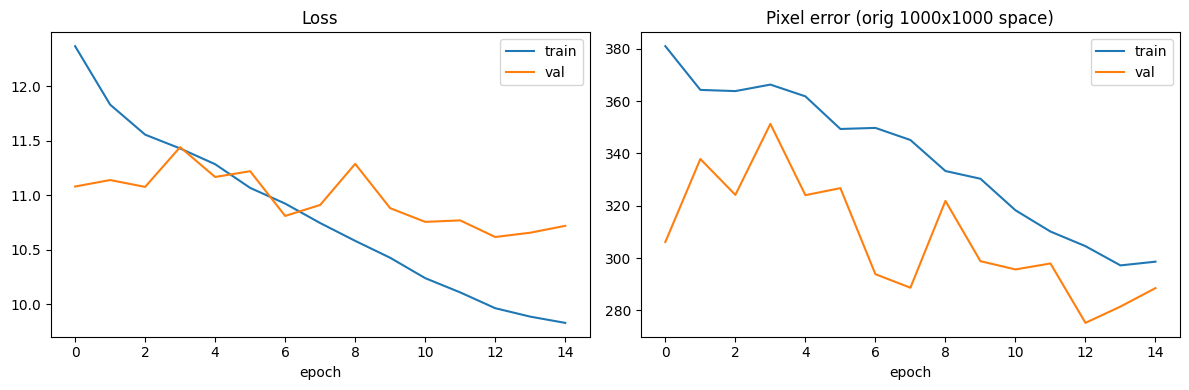

In [12]:
# CELL 12 — Plot training curves
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='train'); axes[0].plot(history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].set_xlabel('epoch'); axes[0].legend()

axes[1].plot(history['train_err'], label='train'); axes[1].plot(history['val_err'], label='val')
axes[1].set_title('Pixel error (orig 1000x1000 space)'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout(); plt.show()


In [13]:
# CELL 13 — Final evaluation on the held-out TEST split
# ---------------------------------------------------------------------------
ckpt = torch.load(BEST_WEIGHTS_PATH, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

errors, rotations = [], []
with torch.no_grad():
    for i in range(len(test_ds)):
        template, search, target = test_ds[i]
        heatmap = model(template.unsqueeze(0).to(device), search.unsqueeze(0).to(device))
        pred_xy, _ = soft_argmax_2d(heatmap)
        err = pixel_error(pred_xy.cpu(), target.unsqueeze(0)).item()
        errors.append(err)
        rotations.append(test_df.iloc[i]['rotation_deg'])

errors = np.array(errors)
print(f"TEST — mean px error: {errors.mean():.2f}   median: {np.median(errors):.2f}   "
      f"90th pct: {np.percentile(errors, 90):.2f}")
for thresh in [5, 10, 20, 50]:
    print(f"  success @ {thresh:>2d}px : {100*(errors < thresh).mean():.1f}%")

res_df = pd.DataFrame({'rotation_deg': rotations, 'error_px': errors})
res_df['rotation_bucket'] = pd.cut(res_df['rotation_deg'].abs(), bins=[-0.01, 0.3, 0.7, 5])
print("\nMean error by |rotation| bucket (harder rotations should show higher error):")
print(res_df.groupby('rotation_bucket', observed=True)['error_px'].mean())


TEST — mean px error: 289.40   median: 263.79   90th pct: 550.75
  success @  5px : 0.0%
  success @ 10px : 0.0%
  success @ 20px : 0.8%
  success @ 50px : 4.2%

Mean error by |rotation| bucket (harder rotations should show higher error):
rotation_bucket
(-0.01, 0.3]    288.139579
(0.3, 0.7]      309.204619
(0.7, 5.0]      269.746594
Name: error_px, dtype: float64


In [14]:
# CELL 14 — Write the STANDALONE inference script
# ---------------------------------------------------------------------------
%%writefile /content/outputs/inference.py
"""
Standalone localization inference script.

Usage:
    python inference.py --reference path/to/reference.png --search path/to/search.png [--weights model_weights.pt]

Prints and returns the predicted center (x, y) in pixel coordinates of the
Search Image (in the ORIGINAL image resolution, e.g. 1000x1000).
Runs with no manual edits, given a weights file trained by this notebook.
"""
import argparse
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image

DEFAULT_WEIGHTS = os.path.join(os.path.dirname(os.path.abspath(__file__)), 'model_weights.pt')


class ConvBlock(nn.Module):
    def __init__(self, c_in, c_out, k=3, stride=1, pool=False):
        super().__init__()
        layers = [nn.Conv2d(c_in, c_out, k, stride=stride, padding=k // 2, bias=False),
                  nn.BatchNorm2d(c_out), nn.ReLU(inplace=True)]
        if pool:
            layers.append(nn.MaxPool2d(2))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class SharedBackbone(nn.Module):
    def __init__(self, c_out=64):
        super().__init__()
        self.net = nn.Sequential(
            ConvBlock(1, 16, k=5, stride=2),
            ConvBlock(16, 32, k=3, stride=1, pool=True),
            ConvBlock(32, 64, k=3, stride=1, pool=True),
            ConvBlock(64, c_out, k=3, stride=1),
        )

    def forward(self, x):
        return self.net(x)


class SiameseLocalizer(nn.Module):
    def __init__(self, feat_dim=64):
        super().__init__()
        self.backbone = SharedBackbone(feat_dim)

    def forward(self, template, search):
        f_t = self.backbone(template)
        f_s = self.backbone(search)
        B, C, t, t2 = f_t.shape
        _, _, H, W = f_s.shape
        f_s_grouped = f_s.reshape(1, B * C, H, W)
        kernel = f_t.reshape(B * C, 1, t, t2)
        response = F.conv2d(f_s_grouped, kernel, groups=B * C)
        response = response.reshape(B, C, response.shape[-2], response.shape[-1]).mean(dim=1, keepdim=True)
        heatmap = F.interpolate(response, size=(search.shape[-2], search.shape[-1]),
                                 mode='bilinear', align_corners=False)
        return heatmap


def soft_argmax_2d(heatmap):
    B, _, H, W = heatmap.shape
    flat = heatmap.view(B, -1)
    probs = F.softmax(flat, dim=1).view(B, 1, H, W)
    xs = torch.linspace(0, 1, W, device=heatmap.device).view(1, 1, 1, W)
    ys = torch.linspace(0, 1, H, device=heatmap.device).view(1, 1, H, 1)
    x = (probs * xs).sum(dim=[1, 2, 3])
    y = (probs * ys).sum(dim=[1, 2, 3])
    return torch.stack([x, y], dim=1), probs


def localize(reference_path, search_path, weights_path=DEFAULT_WEIGHTS, device=None):
    device = device or ('cuda' if torch.cuda.is_available() else 'cpu')
    ckpt = torch.load(weights_path, map_location=device)
    cfg = ckpt.get('config', {'SEARCH_SIZE': 512, 'TEMPLATE_SIZE': 51, 'ORIG_SIZE': 1000.0})

    model = SiameseLocalizer().to(device)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    ref = Image.open(reference_path).convert('L')
    search = Image.open(search_path).convert('L')
    orig_w, orig_h = search.size  # (width, height) of the ORIGINAL search image

    S, T = cfg['SEARCH_SIZE'], cfg['TEMPLATE_SIZE']
    template_np = np.asarray(ref.resize((T, T), Image.BILINEAR), dtype=np.float32) / 255.0
    search_np = np.asarray(search.resize((S, S), Image.BILINEAR), dtype=np.float32) / 255.0

    template_t = torch.from_numpy(template_np).unsqueeze(0).unsqueeze(0).float().to(device)
    search_t = torch.from_numpy(search_np).unsqueeze(0).unsqueeze(0).float().to(device)

    with torch.no_grad():
        heatmap = model(template_t, search_t)
        pred_xy_norm, _ = soft_argmax_2d(heatmap)

    pred_x = pred_xy_norm[0, 0].item() * orig_w
    pred_y = pred_xy_norm[0, 1].item() * orig_h
    return pred_x, pred_y


def main():
    parser = argparse.ArgumentParser(description="Locate a reference SEM pattern inside a search image.")
    parser.add_argument('--reference', required=True, help='Path to reference image')
    parser.add_argument('--search', required=True, help='Path to search image')
    parser.add_argument('--weights', default=DEFAULT_WEIGHTS, help='Path to model_weights.pt')
    args = parser.parse_args()

    x, y = localize(args.reference, args.search, args.weights)
    print(f"{x:.2f},{y:.2f}")
    return x, y


if __name__ == '__main__':
    main()


Writing /content/outputs/inference.py


In [15]:
# CELL 15 — Run the standalone inference script on 30 random TEST pairs
# ---------------------------------------------------------------------------
import sys
sys.path.insert(0, '/content/outputs')
import importlib
import inference as infer_module
importlib.reload(infer_module)

random.seed(7)
sample_idx = random.sample(range(len(test_df)), min(30, len(test_df)))

results = []
for i in sample_idx:
    row = test_df.iloc[i]
    pred_x, pred_y = infer_module.localize(row['ref_full_path'], row['search_full_path'],
                                            weights_path=BEST_WEIGHTS_PATH, device=device)
    gt_x, gt_y = row['center_x'], row['center_y']
    err = math.hypot(pred_x - gt_x, pred_y - gt_y)
    results.append(dict(idx=i, reference_filename=row['reference_filename'], search_image=row['search_image'],
                         pred_x=pred_x, pred_y=pred_y, gt_x=gt_x, gt_y=gt_y, error_px=err))

results_df = pd.DataFrame(results)
print(results_df[['reference_filename','search_image','pred_x','pred_y','gt_x','gt_y','error_px']]
      .round(2).to_string(index=False))
print(f"\nMean error on these 30 examples: {results_df['error_px'].mean():.2f} px")


reference_filename search_image  pred_x  pred_y  gt_x  gt_y  error_px
 reference_252.png search17.png  433.96  297.39 277.5 191.5    188.93
 reference_155.png search11.png  727.99  216.89 649.5  69.5    166.99
 reference_306.png search21.png  593.10  584.18 779.5 709.5    224.62
  reference_54.png  search4.png  599.24  408.46 703.5 163.5    266.22
 reference_142.png search10.png  619.17  568.01 709.5 639.5    115.19
 reference_145.png search10.png  526.78  428.60  74.5 808.5    590.67
 reference_106.png  search8.png  404.36  754.39 389.5 949.5    195.67
 reference_324.png search22.png  696.25  288.07  74.5 808.5    810.81
 reference_148.png search10.png  572.98  404.24 653.5 481.5    111.59
 reference_302.png search21.png  737.21  217.72 789.5 179.5     64.77
 reference_330.png search22.png  287.98  696.00 653.5 481.5    423.81
 reference_143.png search10.png  609.67  564.95 379.5 489.5    242.22
 reference_320.png search22.png  637.26  422.35 499.5 499.5    157.90
 reference_163.png s

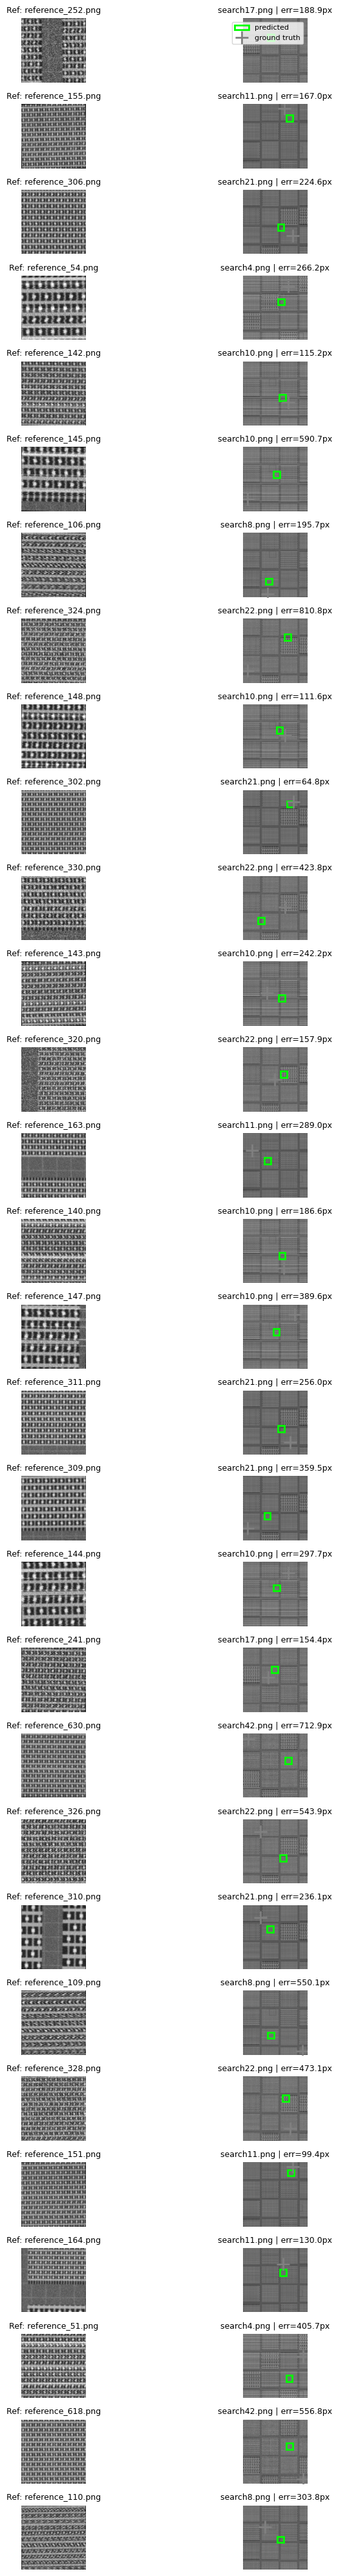

Saved visualization to /content/outputs/example_predictions.png


In [16]:
# CELL 16 — Visualize all 30 examples: reference
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(30, 2, figsize=(9, 40))

for row_i, res in enumerate(results):
    df_row = test_df.iloc[res['idx']]
    ref_img = Image.open(df_row['ref_full_path']).convert('L')
    search_img = Image.open(df_row['search_full_path']).convert('L')

    axes[row_i, 0].imshow(ref_img, cmap='gray')
    axes[row_i, 0].set_title(f"Ref: {res['reference_filename']}", fontsize=9)
    axes[row_i, 0].axis('off')

    axes[row_i, 1].imshow(search_img, cmap='gray')

    # predicted -> green bounding box, centered on the predicted point, sized to the
    # known pattern footprint (x2-x1 / y2-y1 from the CSV, ~100px in your dataset)
    box_w = df_row['x2'] - df_row['x1']
    box_h = df_row['y2'] - df_row['y1']
    pred_rect = plt.Rectangle(
        (res['pred_x'] - box_w / 2, res['pred_y'] - box_h / 2), box_w, box_h,
        edgecolor='lime', facecolor='none', linewidth=2, label='predicted'
    )
    axes[row_i, 1].add_patch(pred_rect)

    # ground truth -> gray plus marker
    axes[row_i, 1].plot(res['gt_x'], res['gt_y'], '+', color='gray',
                         markersize=14, markeredgewidth=2, label='ground truth')

    axes[row_i, 1].set_title(f"{res['search_image']} | err={res['error_px']:.1f}px", fontsize=9)
    axes[row_i, 1].axis('off')
    if row_i == 0:
        axes[row_i, 1].legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('/content/outputs/example_predictions.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved visualization to /content/outputs/example_predictions.png")


In [17]:
# CELL 17 — Package everything in /content/outputs
# ---------------------------------------------------------------------------
print("Contents of /content/outputs:")
for f in sorted(os.listdir('/content/outputs')):
    path = os.path.join('/content/outputs', f)
    size_kb = os.path.getsize(path) / 1024
    print(f"  {f:35s}  {size_kb:8.1f} KB")

print("\nExample CLI usage (run the standalone script exactly like a grader would):")
example_row = test_df.iloc[0]
print(f"python /content/outputs/inference.py "
      f"--reference \"{example_row['ref_full_path']}\" "
      f"--search \"{example_row['search_full_path']}\" "
      f"--weights /content/outputs/model_weights.pt")


Contents of /content/outputs:
  __pycache__                               4.0 KB
  example_predictions.png                1668.0 KB
  inference.py                              4.4 KB
  model_weights.pt                        247.8 KB

Example CLI usage (run the standalone script exactly like a grader would):
python /content/outputs/inference.py --reference "/content/DriftSense_Prepared/test/reference/reference_136.png" --search "/content/DriftSense_Prepared/test/search/search10.png" --weights /content/outputs/model_weights.pt


In [18]:
# CELL 20 — Install ONNX tooling & export the trained model to ONNX
# ---------------------------------------------------------------------------
!pip install -q onnx onnxruntime

import onnx
import onnxruntime as ort

class ONNXExportWrapper(nn.Module):
    """Wraps SiameseLocalizer + soft-argmax so the exported graph outputs (x, y) directly,
    in NORMALIZED [0,1] coords w.r.t. the resized search image (same convention as training)."""
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

    def forward(self, template, search):
        heatmap = self.base_model(template, search)
        pred_xy, _ = soft_argmax_2d(heatmap)   # [1, 2] -> (x_norm, y_norm)
        return pred_xy

# reload best weights to be safe
ckpt = torch.load(BEST_WEIGHTS_PATH, map_location=device)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()

export_model = ONNXExportWrapper(model).to(device).eval()


T, S = CONFIG['TEMPLATE_SIZE'], CONFIG['SEARCH_SIZE']
dummy_template = torch.randn(1, 1, T, T, device=device)
dummy_search   = torch.randn(1, 1, S, S, device=device)

ONNX_PATH = '/content/outputs/model.onnx'

torch.onnx.export(
    export_model,
    (dummy_template, dummy_search),
    ONNX_PATH,
    input_names=['template', 'search'],
    output_names=['pred_xy'],
    opset_version=13,
    do_constant_folding=True,
    dynamic_axes=None,
    dynamo=False, # fixed shapes: batch=1, template=TxT, search=SxS (matches CONFIG)
)

onnx_model = onnx.load(ONNX_PATH)
onnx.checker.check_model(onnx_model)
print("ONNX export OK — graph is valid.")

pt_size_kb = os.path.getsize(BEST_WEIGHTS_PATH) / 1024
onnx_size_kb = os.path.getsize(ONNX_PATH) / 1024
print(f"\n{'File':20s} {'Size (KB)':>12s}")
print(f"{'model_weights.pt':20s} {pt_size_kb:12.1f}")
print(f"{'model.onnx':20s} {onnx_size_kb:12.1f}")

import json
with open('/content/outputs/model_onnx_config.json', 'w') as f:
    json.dump(CONFIG, f, indent=2)
print("\nSaved config to /content/outputs/model_onnx_config.json (needed at ONNX inference time)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.1/19.1 MB 97.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 78.7 MB/s eta 0:00:00


/tmp/ipykernel_725/1489479566.py:34: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


ONNX export OK — graph is valid.

File                    Size (KB)
model_weights.pt            247.8
model.onnx                  249.9

Saved config to /content/outputs/model_onnx_config.json (needed at ONNX inference time)
